In [ ]:
from pathlib import Path

from IPython.display import Image, Markdown, display



STATIC_IMAGE_DIR = Path("/kaggle/input/notebook-static-images-public")

display(Markdown("## Saved analysis figures"))

for image_path in sorted(STATIC_IMAGE_DIR.glob("tcr-*.png")):

    display(Markdown(f"**{image_path.stem}**"))

    display(Image(filename=str(image_path)))

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

DATA_DIR = Path('/home/Data_Drive_8TB/kykim/7. Kaggle/TCR_Specificity_Prediction_Challenge')
TRAIN_PATH = DATA_DIR / 'train.csv'
TEST_PATH = DATA_DIR / 'test.csv'
SAMPLE_SUBMISSION_PATH = DATA_DIR / 'sample_submission.csv'
OUTPUT_DIR = Path('/home/Data_Drive_8TB/kykim/0. Jupyter/Kaggle/TCR-pred/output')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
sample_submission = pd.read_csv(SAMPLE_SUBMISSION_PATH)

print('train:', train.shape)
print('test:', test.shape)
print('sample_submission:', sample_submission.shape)
print('\ntrain columns:', train.columns.tolist())
print('\ntest columns:', test.columns.tolist())
print('\nsample_submission columns:', sample_submission.columns.tolist())
print('\nNo explicit label in train:', 'Prediction' not in train.columns)

train: (39926, 20)
test: (8938, 19)
sample_submission: (8938, 20)

train columns: ['DB', 'Peptide', 'HLA', 'Va', 'Ja', 'CDR1a', 'CDR2a', 'CDR3a', 'CDR3a_extended', 'TCRa', 'Vb', 'Jb', 'CDR1b', 'CDR2b', 'CDR3b', 'CDR3b_extended', 'TCRb', 'references', 'receptor_id', 'just_10X']

test columns: ['ID', 'CDR1a', 'CDR2a', 'CDR3a', 'Va', 'Va_adaptive', 'Ja', 'Ja_adaptive', 'TCRa', 'CDR1b', 'CDR2b', 'CDR3b', 'Vb', 'Vb_adaptive', 'Jb', 'Jb_adaptive', 'TCRb', 'Peptide', 'HLA']

sample_submission columns: ['ID', 'CDR1a', 'CDR2a', 'CDR3a', 'Va', 'Va_adaptive', 'Ja', 'Ja_adaptive', 'TCRa', 'CDR1b', 'CDR2b', 'CDR3b', 'Vb', 'Vb_adaptive', 'Jb', 'Jb_adaptive', 'TCRb', 'Peptide', 'HLA', 'Prediction']

No explicit label in train: True


# ImmRep25 TCR specificity prediction

In [2]:
import math
import random
import warnings
from collections import defaultdict
from dataclasses import dataclass

import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    from torch.utils.data import DataLoader, Dataset, Sampler
    TORCH_AVAILABLE = True
except ImportError:
    TORCH_AVAILABLE = False
    print('PyTorch is not installed in the active kernel. Install torch before running model cells.')

try:
    from sklearn.metrics import average_precision_score, roc_auc_score
    from sklearn.model_selection import GroupShuffleSplit
    SKLEARN_AVAILABLE = True
except ImportError:
    SKLEARN_AVAILABLE = False
    print('scikit-learn is not installed in the active kernel. Install scikit-learn before splitting/evaluation.')

In [3]:
def add_sequence_features(df):
    df = df.copy()
    df['alpha_seq'] = df['CDR3a_extended'].fillna(df['CDR3a']) if 'CDR3a_extended' in df.columns else df['CDR3a']
    df['beta_seq'] = df['CDR3b_extended'].fillna(df['CDR3b']) if 'CDR3b_extended' in df.columns else df['CDR3b']
    df['peptide_seq'] = df['Peptide']
    for col in ['alpha_seq', 'beta_seq', 'peptide_seq']:
        df[col] = df[col].fillna('').astype(str).str.upper()
        df[f'{col}_len'] = df[col].str.len()
    return df

train_eda = add_sequence_features(train)
test_eda = add_sequence_features(test)

summary = pd.DataFrame({
    'train_missing': train.isna().sum(),
    'train_unique': train.nunique(dropna=True),
}).sort_index()

print('Train positives only:', 'Prediction' not in train.columns)
print('Train rows:', len(train_eda), 'Test rows:', len(test_eda))
print('Unique HLA:', train_eda['HLA'].nunique(), 'Unique peptide:', train_eda['Peptide'].nunique())
print('Unique receptor_id:', train_eda['receptor_id'].nunique() if 'receptor_id' in train_eda.columns else 'NA')
display(summary)

display(train_eda[['alpha_seq_len', 'beta_seq_len', 'peptide_seq_len']].describe().round(2))
display(train_eda['HLA'].value_counts().head(15).rename_axis('HLA').reset_index(name='count'))
display(train_eda['Peptide'].value_counts().head(15).rename_axis('Peptide').reset_index(name='count'))

Train positives only: True
Train rows: 39926 Test rows: 8938
Unique HLA: 71 Unique peptide: 1457
Unique receptor_id: 39119


,train_missing,train_unique
CDR1a,0,49
CDR1b,0,43
CDR2a,0,45
CDR2b,0,51
CDR3a,0,29590
CDR3a_extended,0,29597
CDR3b,0,31910
CDR3b_extended,0,31910
DB,0,2
HLA,0,71


,alpha_seq_len,beta_seq_len,peptide_seq_len
count,39926.00,39926.00,39926.00
mean,15.10,15.94,9.11
std,2.21,2.04,0.55
min,5.00,7.00,7.00
25%,14.00,15.00,9.00
50%,15.00,16.00,9.00
75%,17.00,17.00,9.00
max,30.00,28.00,25.00


,HLA,count
0,HLA-A*03:01,15045
1,HLA-A*02:01,13672
2,HLA-A*11:01,2512
3,HLA-B*08:01,2147
4,HLA-B*07:02,1968
5,HLA-A*01:01,1966
6,HLA-A*24:02,768
7,HLA-E*01:03,371
8,HLA-B*15:01,239
9,HLA-A*68:01,186


,Peptide,count
0,KLGGALQAK,13671
1,GILGFVFTL,4016
2,AVFDRKSDAK,1716
3,RAKFKQLL,1630
4,YLQPRTFLL,845
5,SPRWYFYYL,827
6,GLCTLVAML,782
7,TTDPSFLGRY,782
8,IVTDFSVIK,696
9,RVRAYTYSK,689


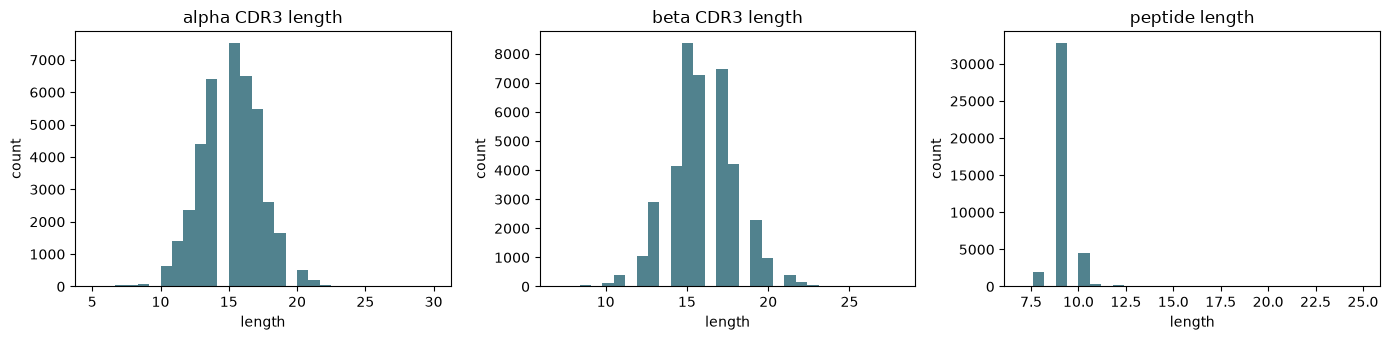

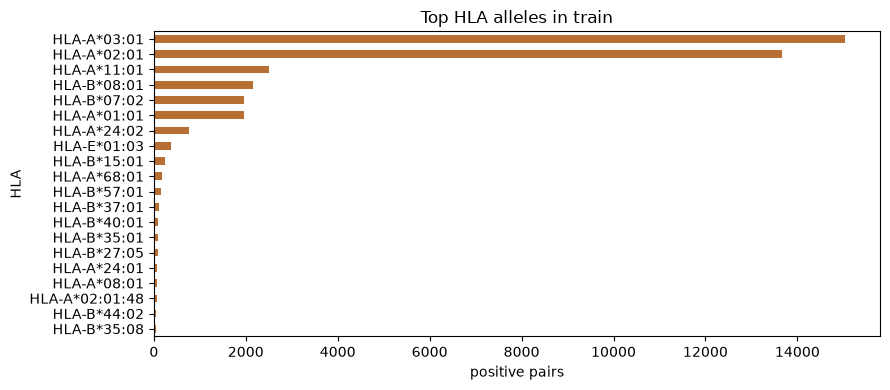

Test peptide overlap with train: 0.000
Test HLA overlap with train: 1.000


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for ax, col, title in zip(
    axes,
    ['alpha_seq_len', 'beta_seq_len', 'peptide_seq_len'],
    ['alpha CDR3 length', 'beta CDR3 length', 'peptide length'],
):
    ax.hist(train_eda[col], bins=30, color='#326c7a', alpha=0.85)
    ax.set_title(title)
    ax.set_xlabel('length')
    ax.set_ylabel('count')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 4))
train_eda['HLA'].value_counts().head(20).sort_values().plot(kind='barh', ax=ax, color='#b86f33')
ax.set_title('Top HLA alleles in train')
ax.set_xlabel('positive pairs')
plt.tight_layout()
plt.show()

overlap_peptide = len(set(test_eda['Peptide']) & set(train_eda['Peptide'])) / test_eda['Peptide'].nunique()
overlap_hla = len(set(test_eda['HLA']) & set(train_eda['HLA'])) / test_eda['HLA'].nunique()
print(f'Test peptide overlap with train: {overlap_peptide:.3f}')
print(f'Test HLA overlap with train: {overlap_hla:.3f}')

## Training table


In [5]:
def make_hla_shuffled_negatives(df, negatives_per_positive=1, seed=42):
    rng = np.random.default_rng(seed)
    positive = add_sequence_features(df)
    positive = positive[['alpha_seq', 'beta_seq', 'peptide_seq', 'HLA', 'receptor_id']].copy()
    positive['label'] = 1.0

    positive_keys = set(zip(positive['alpha_seq'], positive['beta_seq'], positive['peptide_seq'], positive['HLA']))
    negative_parts = []

    for hla, group in positive.groupby('HLA', sort=False):
        peptides = group['peptide_seq'].to_numpy()
        if len(np.unique(peptides)) < 2:
            continue

        generated = []
        attempts = 0
        target = len(group) * negatives_per_positive
        rows = group[['alpha_seq', 'beta_seq', 'peptide_seq', 'HLA', 'receptor_id']].to_dict('records')
        while len(generated) < target and attempts < target * 20:
            base = rows[attempts % len(rows)].copy()
            new_peptide = rng.choice(peptides)
            attempts += 1
            if new_peptide == base['peptide_seq']:
                continue
            key = (base['alpha_seq'], base['beta_seq'], new_peptide, hla)
            if key in positive_keys:
                continue
            base['peptide_seq'] = new_peptide
            base['label'] = 0.0
            generated.append(base)

        if generated:
            negative_parts.append(pd.DataFrame(generated))

    negatives = pd.concat(negative_parts, ignore_index=True) if negative_parts else positive.iloc[0:0].copy()
    train_pairs = pd.concat([positive, negatives], ignore_index=True)
    train_pairs = train_pairs.sample(frac=1, random_state=seed).reset_index(drop=True)
    return train_pairs

train_pairs = make_hla_shuffled_negatives(train, negatives_per_positive=1, seed=SEED)
print(train_pairs['label'].value_counts())
print('Rows:', train_pairs.shape)
display(train_pairs.head())

label
1.0    39926
0.0    39793
Name: count, dtype: int64
Rows: (79719, 6)


,alpha_seq,beta_seq,peptide_seq,HLA,receptor_id,label
0,CCLVGDIQGGGGKLIFF,CCSVEGDTGELFFF,GILGFVFTL,HLA-A*02:01,"complex.id.12453,complex.id.12322",0.0
1,CCAVNKGGGSQGNLIFF,CCASSIRASYEQYFF,FLIYLDVSV,HLA-A*02:01,complex.id.9902,0.0
2,CCAGTFAGSARQLTFF,CCASSSPWGTEAFFF,FLRGRAYGL,HLA-B*08:01,complex.id.43310,0.0
3,CCAVARKTSYDKVIFF,CCASNGRGIQETQYFF,KLGGALQAK,HLA-A*03:01,complex.id.26180,1.0
4,CCALGGSQGNLIFF,CCASSFRSGQDTQYFF,CTELKLSDY,HLA-A*01:01,complex.id.37884,0.0


In [6]:
AMINO_ACIDS = list('ACDEFGHIKLMNPQRSTVWY')
SPECIAL_TOKENS = ['<pad>', '<unk>', '<cls>']
itos = SPECIAL_TOKENS + AMINO_ACIDS
stoi = {token: idx for idx, token in enumerate(itos)}
PAD_IDX = stoi['<pad>']
UNK_IDX = stoi['<unk>']
CLS_IDX = stoi['<cls>']

MAX_ALPHA_LEN = int(np.percentile(train_pairs['alpha_seq'].str.len(), 99))
MAX_BETA_LEN = int(np.percentile(train_pairs['beta_seq'].str.len(), 99))
MAX_PEPTIDE_LEN = max(8, int(np.percentile(train_pairs['peptide_seq'].str.len(), 99)))
MAX_ALPHA_LEN = min(max(MAX_ALPHA_LEN, 12), 40)
MAX_BETA_LEN = min(max(MAX_BETA_LEN, 12), 40)
MAX_PEPTIDE_LEN = min(max(MAX_PEPTIDE_LEN, 8), 20)

hla_values = sorted(set(train_pairs['HLA']) | set(test_eda['HLA']))
hla_to_idx = {hla: idx for idx, hla in enumerate(hla_values)}

print('max lengths:', {'alpha': MAX_ALPHA_LEN, 'beta': MAX_BETA_LEN, 'peptide': MAX_PEPTIDE_LEN})
print('vocab size:', len(itos), 'HLA classes:', len(hla_to_idx))


def encode_sequence(seq, max_len):
    tokens = [CLS_IDX] + [stoi.get(char, UNK_IDX) for char in str(seq).upper()[: max_len - 1]]
    if len(tokens) < max_len:
        tokens += [PAD_IDX] * (max_len - len(tokens))
    return np.array(tokens, dtype=np.int64)


def build_model_frame(df):
    out = add_sequence_features(df)
    out = out.rename(columns={'HLA': 'hla'})
    keep_cols = ['alpha_seq', 'beta_seq', 'peptide_seq', 'hla']
    if 'label' in out.columns:
        keep_cols.append('label')
    if 'receptor_id' in out.columns:
        keep_cols.append('receptor_id')
    if 'ID' in out.columns:
        keep_cols.append('ID')
    return out[keep_cols].copy()

max lengths: {'alpha': 20, 'beta': 21, 'peptide': 11}
vocab size: 23 HLA classes: 71


In [7]:
class TCRDataset(Dataset):
    def __init__(self, frame, include_label=True):
        self.frame = frame.reset_index(drop=True)
        self.include_label = include_label

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        item = {
            'alpha': torch.tensor(encode_sequence(row['alpha_seq'], MAX_ALPHA_LEN), dtype=torch.long),
            'beta': torch.tensor(encode_sequence(row['beta_seq'], MAX_BETA_LEN), dtype=torch.long),
            'peptide': torch.tensor(encode_sequence(row['peptide_seq'], MAX_PEPTIDE_LEN), dtype=torch.long),
            'hla': torch.tensor(hla_to_idx.get(row['hla'], 0), dtype=torch.long),
        }
        if self.include_label:
            item['label'] = torch.tensor(row['label'], dtype=torch.float32)
        return item


class HLABatchSampler(Sampler):
    def __init__(self, frame, batch_size=256, shuffle=True, seed=42):
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.seed = seed
        self.epoch = 0
        self.groups = defaultdict(list)
        for idx, hla in enumerate(frame['hla']):
            self.groups[hla].append(idx)

    def __iter__(self):
        rng = random.Random(self.seed + self.epoch)
        batches = []
        for indices in self.groups.values():
            indices = indices.copy()
            if self.shuffle:
                rng.shuffle(indices)
            for start in range(0, len(indices), self.batch_size):
                batch = indices[start:start + self.batch_size]
                if batch:
                    batches.append(batch)
        if self.shuffle:
            rng.shuffle(batches)
        self.epoch += 1
        return iter(batches)

    def __len__(self):
        return sum(math.ceil(len(indices) / self.batch_size) for indices in self.groups.values())


def split_train_valid(frame, test_size=0.15, seed=42):
    if not SKLEARN_AVAILABLE:
        raise ImportError('Install scikit-learn to use GroupShuffleSplit.')
    groups = frame['receptor_id'].astype(str) if 'receptor_id' in frame.columns else frame['alpha_seq'] + '_' + frame['beta_seq']
    splitter = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
    train_idx, valid_idx = next(splitter.split(frame, frame['label'], groups=groups))
    return frame.iloc[train_idx].reset_index(drop=True), frame.iloc[valid_idx].reset_index(drop=True)

model_frame = train_pairs.rename(columns={'HLA': 'hla'})
train_frame, valid_frame = split_train_valid(model_frame, test_size=0.15, seed=SEED)
print(train_frame.shape, valid_frame.shape)
print('valid label balance:', valid_frame['label'].mean().round(3))

(67821, 6) (11898, 6)
valid label balance: 0.504


## RoPE triadic Transformer

요청한 `Q=CDR3b`, `K=CDR3a`, `V=Peptide` 구조는 Q/K와 V의 sequence length가 서로 달라 그대로는 행렬곱이 맞지 않습니다. 여기서는 peptide value embedding을 alpha-key 길이로 1D 보간한 뒤, beta query가 alpha key에 attention하고 peptide value를 읽도록 구현합니다. 이후 beta token에는 causal mask decoder block을 적용합니다.

In [31]:
def lengths_from_tokens(tokens):
    return (tokens != PAD_IDX).sum(dim=1).clamp(min=1)


def masked_mean(x, tokens):
    mask = (tokens != PAD_IDX).unsqueeze(-1)
    summed = (x * mask).sum(dim=1)
    denom = mask.sum(dim=1).clamp(min=1)
    return summed / denom


def rotate_half(x):
    x1 = x[..., ::2]
    x2 = x[..., 1::2]
    return torch.stack((-x2, x1), dim=-1).flatten(-2)


def apply_rope(x):
    seq_len = x.size(-2)
    dim = x.size(-1)
    device = x.device
    inv_freq = 1.0 / (10000 ** (torch.arange(0, dim, 2, device=device).float() / dim))
    positions = torch.arange(seq_len, device=device).float()
    freqs = torch.einsum('i,j->ij', positions, inv_freq)
    emb = torch.repeat_interleave(freqs, repeats=2, dim=-1)
    return (x * emb.cos()) + (rotate_half(x) * emb.sin())


def sinusoidal_encoding(seq_len, dim, device):
    positions = torch.arange(seq_len, device=device).float().unsqueeze(1)
    div_term = torch.exp(torch.arange(0, dim, 2, device=device).float() * (-math.log(10000.0) / dim))
    pe = torch.zeros(seq_len, dim, device=device)
    pe[:, 0::2] = torch.sin(positions * div_term)
    pe[:, 1::2] = torch.cos(positions * div_term)
    return pe.unsqueeze(0)


class RoPETriadicAttention(nn.Module):
    def __init__(self, dim, heads=4, dropout=0.1, positional_encoding='rope'):
        super().__init__()
        if dim % heads != 0:
            raise ValueError('dim must be divisible by heads')
        self.heads = heads
        self.head_dim = dim // heads
        self.positional_encoding = positional_encoding
        self.last_attention = None
        self.q_proj = nn.Linear(dim, dim)
        self.k_proj = nn.Linear(dim, dim)
        self.v_proj = nn.Linear(dim, dim)
        self.out_proj = nn.Linear(dim, dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, beta_x, alpha_x, peptide_x, alpha_tokens):
        batch_size, beta_len, dim = beta_x.shape
        alpha_len = alpha_x.size(1)

        q = self.q_proj(beta_x).view(batch_size, beta_len, self.heads, self.head_dim).transpose(1, 2)
        k = self.k_proj(alpha_x).view(batch_size, alpha_len, self.heads, self.head_dim).transpose(1, 2)

        peptide_value = F.interpolate(
            peptide_x.transpose(1, 2),
            size=alpha_len,
            mode='linear',
            align_corners=False,
        ).transpose(1, 2)
        v = self.v_proj(peptide_value).view(batch_size, alpha_len, self.heads, self.head_dim).transpose(1, 2)

        if self.positional_encoding == 'rope':
            q = apply_rope(q)
            k = apply_rope(k)
        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        key_mask = (alpha_tokens != PAD_IDX).unsqueeze(1).unsqueeze(2)
        scores = scores.masked_fill(~key_mask, torch.finfo(scores.dtype).min)
        attn = torch.softmax(scores, dim=-1)
        self.last_attention = attn.detach().cpu()
        context = torch.matmul(self.dropout(attn), v).transpose(1, 2).contiguous().view(batch_size, beta_len, dim)
        return self.out_proj(context)


class MaskedDecoderBlock(nn.Module):
    def __init__(self, dim, heads=4, dropout=0.1):
        super().__init__()
        self.self_attn = nn.MultiheadAttention(dim, heads, dropout=dropout, batch_first=True)
        self.norm1 = nn.LayerNorm(dim)
        self.norm2 = nn.LayerNorm(dim)
        self.ffn = nn.Sequential(
            nn.Linear(dim, dim * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim * 4, dim),
        )
        self.dropout = nn.Dropout(dropout)
        self.last_self_attention = None

    def forward(self, x, tokens):
        seq_len = x.size(1)
        causal_mask = torch.triu(torch.ones(seq_len, seq_len, device=x.device, dtype=torch.bool), diagonal=1)
        key_padding_mask = tokens == PAD_IDX
        attn_out, attn_weights = self.self_attn(
            x,
            x,
            x,
            attn_mask=causal_mask,
            key_padding_mask=key_padding_mask,
            need_weights=True,
            average_attn_weights=False,
        )
        self.last_self_attention = attn_weights.detach().cpu()
        x = self.norm1(x + self.dropout(attn_out))
        x = self.norm2(x + self.dropout(self.ffn(x)))
        return x


class TCRBindingTransformer(nn.Module):
    def __init__(self, vocab_size, hla_count, dim=128, heads=4, dropout=0.15, decoder_layers=2, positional_encoding='rope'):
        super().__init__()
        if positional_encoding not in {'rope', 'sinusoidal', 'none'}:
            raise ValueError("positional_encoding must be one of {'rope', 'sinusoidal', 'none'}")
        self.positional_encoding = positional_encoding
        self.token_embedding = nn.Embedding(vocab_size, dim, padding_idx=PAD_IDX)
        self.hla_embedding = nn.Embedding(hla_count, dim)
        self.alpha_encoder = nn.Sequential(nn.LayerNorm(dim), nn.Dropout(dropout))
        self.beta_encoder = nn.Sequential(nn.LayerNorm(dim), nn.Dropout(dropout))
        self.peptide_encoder = nn.Sequential(nn.LayerNorm(dim), nn.Dropout(dropout))
        self.triadic_attention = RoPETriadicAttention(dim, heads=heads, dropout=dropout, positional_encoding=positional_encoding)
        self.decoder = nn.ModuleList([MaskedDecoderBlock(dim, heads=heads, dropout=dropout) for _ in range(decoder_layers)])
        self.classifier = nn.Sequential(
            nn.LayerNorm(dim * 4),
            nn.Linear(dim * 4, dim * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim * 2, 1),
        )

    def add_absolute_position(self, x):
        if self.positional_encoding != 'sinusoidal':
            return x
        return x + sinusoidal_encoding(x.size(1), x.size(2), x.device)

    def forward(self, alpha, beta, peptide, hla):
        hla_bias = self.hla_embedding(hla).unsqueeze(1)
        alpha_x = self.add_absolute_position(self.token_embedding(alpha)) + hla_bias
        beta_x = self.add_absolute_position(self.token_embedding(beta)) + hla_bias
        peptide_x = self.add_absolute_position(self.token_embedding(peptide)) + hla_bias
        alpha_x = self.alpha_encoder(alpha_x)
        beta_x = self.beta_encoder(beta_x)
        peptide_x = self.peptide_encoder(peptide_x)

        triadic = self.triadic_attention(beta_x, alpha_x, peptide_x, alpha)
        x = beta_x + triadic
        for block in self.decoder:
            x = block(x, beta)

        pooled_beta = masked_mean(x, beta)
        pooled_alpha = masked_mean(alpha_x, alpha)
        pooled_peptide = masked_mean(peptide_x, peptide)
        pooled_hla = self.hla_embedding(hla)
        features = torch.cat([pooled_beta, pooled_alpha, pooled_peptide, pooled_hla], dim=1)
        return self.classifier(features).squeeze(1)

In [23]:
@dataclass
class TrainConfig:
    batch_size: int = 256
    dim: int = 128
    heads: int = 4
    dropout: float = 0.15
    decoder_layers: int = 2
    positional_encoding: str = 'rope'
    epochs: int = 100
    early_stopping_patience: int = 10
    min_auc_delta: float = 1e-4
    max_lr: float = 2e-3
    weight_decay: float = 1e-2
    grad_clip: float = 1.0
    quick_run: bool = False
    quick_rows: int = 6000


config = TrainConfig()
device = torch.device('cuda' if TORCH_AVAILABLE and torch.cuda.is_available() else 'cpu') if TORCH_AVAILABLE else None
print(config)
print('device:', device)

active_frame = model_frame
valid_size = 0.15
if config.quick_run:
    active_frame = model_frame.sample(min(len(model_frame), config.quick_rows), random_state=SEED).reset_index(drop=True)
    valid_size = 0.2
    print('Quick run enabled:', active_frame.shape)

train_frame, valid_frame = split_train_valid(active_frame, test_size=valid_size, seed=SEED)
train_dataset = TCRDataset(train_frame, include_label=True)
valid_dataset = TCRDataset(valid_frame, include_label=True)
train_loader = DataLoader(
    train_dataset,
    batch_sampler=HLABatchSampler(train_frame, batch_size=config.batch_size, shuffle=True, seed=SEED),
    num_workers=0,
)
valid_loader = DataLoader(valid_dataset, batch_size=config.batch_size * 2, shuffle=False, num_workers=0)

batch = next(iter(train_loader))
print('train/valid:', train_frame.shape, valid_frame.shape)
print({key: tuple(value.shape) for key, value in batch.items()})

TrainConfig(batch_size=256, dim=128, heads=4, dropout=0.15, decoder_layers=2, positional_encoding='rope', epochs=100, early_stopping_patience=10, min_auc_delta=0.0001, max_lr=0.002, weight_decay=0.01, grad_clip=1.0, quick_run=False, quick_rows=6000)
device: cuda
train/valid: (67821, 6) (11898, 6)
{'alpha': (256, 20), 'beta': (256, 21), 'peptide': (256, 11), 'hla': (256,), 'label': (256,)}


In [24]:
for pe_name in ['rope', 'sinusoidal']:
    smoke_model = TCRBindingTransformer(
        vocab_size=len(itos),
        hla_count=len(hla_to_idx),
        dim=config.dim,
        heads=config.heads,
        dropout=config.dropout,
        decoder_layers=config.decoder_layers,
        positional_encoding=pe_name,
    ).to(device)
    smoke_batch = {key: value.to(device) for key, value in batch.items()}
    with torch.no_grad():
        smoke_logits = smoke_model(smoke_batch['alpha'], smoke_batch['beta'], smoke_batch['peptide'], smoke_batch['hla'])
    print(pe_name, 'smoke logits shape:', tuple(smoke_logits.shape))
    print(pe_name, 'smoke logits range:', float(smoke_logits.min()), float(smoke_logits.max()))
    del smoke_model, smoke_logits

rope smoke logits shape: (256,)
rope smoke logits range: -0.3824160695075989 0.28339534997940063
sinusoidal smoke logits shape: (256,)
sinusoidal smoke logits range: -0.1305176019668579 0.35557714104652405


In [25]:
def batch_to_device(batch, device):
    return {key: value.to(device) for key, value in batch.items()}


def evaluate(model, loader, device):
    model.eval()
    losses = []
    y_true = []
    y_prob = []
    with torch.no_grad():
        for batch in loader:
            batch = batch_to_device(batch, device)
            logits = model(batch['alpha'], batch['beta'], batch['peptide'], batch['hla'])
            loss = F.binary_cross_entropy_with_logits(logits, batch['label'])
            probs = torch.sigmoid(logits)
            losses.append(loss.item())
            y_true.extend(batch['label'].detach().cpu().numpy().tolist())
            y_prob.extend(probs.detach().cpu().numpy().tolist())
    metrics = {'loss': float(np.mean(losses))}
    if len(set(y_true)) > 1 and SKLEARN_AVAILABLE:
        metrics['auc'] = float(roc_auc_score(y_true, y_prob))
        metrics['auprc'] = float(average_precision_score(y_true, y_prob))
    return metrics


def train_one_model(config, train_loader, valid_loader, run_name=None):
    if not TORCH_AVAILABLE:
        raise ImportError('PyTorch is required for training.')
    if not SKLEARN_AVAILABLE:
        raise ImportError('scikit-learn is required because early stopping is based on valid AUC.')

    run_name = run_name or f'{config.positional_encoding}_tcr_transformer'
    model = TCRBindingTransformer(
        vocab_size=len(itos),
        hla_count=len(hla_to_idx),
        dim=config.dim,
        heads=config.heads,
        dropout=config.dropout,
        decoder_layers=config.decoder_layers,
        positional_encoding=config.positional_encoding,
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=config.max_lr, weight_decay=config.weight_decay)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=config.max_lr,
        epochs=config.epochs,
        steps_per_epoch=len(train_loader),
        pct_start=0.15,
        div_factor=10,
        final_div_factor=100,
    )
    scaler = torch.cuda.amp.GradScaler(enabled=device.type == 'cuda')
    best_auc = -np.inf
    best_epoch = 0
    epochs_without_improvement = 0
    history = []
    best_path = OUTPUT_DIR / f'best_{run_name}.pt'

    for epoch in range(1, config.epochs + 1):
        model.train()
        train_losses = []
        for batch in train_loader:
            batch = batch_to_device(batch, device)
            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=device.type == 'cuda'):
                logits = model(batch['alpha'], batch['beta'], batch['peptide'], batch['hla'])
                loss = F.binary_cross_entropy_with_logits(logits, batch['label'])
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), config.grad_clip)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            train_losses.append(loss.item())

        valid_metrics = evaluate(model, valid_loader, device)
        valid_auc = valid_metrics.get('auc', np.nan)
        improved = valid_auc > best_auc + config.min_auc_delta
        if improved:
            best_auc = valid_auc
            best_epoch = epoch
            epochs_without_improvement = 0
            torch.save(
                {
                    'model': model.state_dict(),
                    'config': config.__dict__,
                    'hla_to_idx': hla_to_idx,
                    'itos': itos,
                    'best_epoch': best_epoch,
                    'best_valid_auc': best_auc,
                    'run_name': run_name,
                    'positional_encoding': config.positional_encoding,
                },
                best_path,
            )
        else:
            epochs_without_improvement += 1

        row = {
            'run_name': run_name,
            'positional_encoding': config.positional_encoding,
            'epoch': epoch,
            'train_loss': float(np.mean(train_losses)),
            'valid_loss': valid_metrics['loss'],
            'valid_auc': valid_auc,
            'valid_auprc': valid_metrics.get('auprc', np.nan),
            'lr': scheduler.get_last_lr()[0],
            'best_valid_auc': best_auc,
            'best_epoch': best_epoch,
            'epochs_without_improvement': epochs_without_improvement,
            'is_best': improved,
        }
        history.append(row)
        print(row)

        if epochs_without_improvement >= config.early_stopping_patience:
            print(f'Early stopping at epoch {epoch}. Best valid AUC {best_auc:.5f} at epoch {best_epoch}.')
            break

    checkpoint = torch.load(best_path, map_location=device)
    model.load_state_dict(checkpoint['model'])
    print(f'Loaded best model from epoch {checkpoint["best_epoch"]} with valid AUC {checkpoint["best_valid_auc"]:.5f}.')
    return model, pd.DataFrame(history), best_path

{'epoch': 1, 'train_loss': 0.6257021071002948, 'valid_loss': 0.5659678727388382, 'valid_auc': 0.7478769364475018, 'valid_auprc': 0.7467863899304787, 'lr': 0.00021967525067242998, 'best_valid_auc': 0.7478769364475018, 'best_epoch': 1, 'epochs_without_improvement': 0, 'is_best': True}
{'epoch': 2, 'train_loss': 0.5590630769268278, 'valid_loss': 0.5450322329998016, 'valid_auc': 0.7745036379692274, 'valid_auprc': 0.7643945988675118, 'lr': 0.00027784074604744616, 'best_valid_auc': 0.7745036379692274, 'best_epoch': 2, 'epochs_without_improvement': 0, 'is_best': True}
{'epoch': 3, 'train_loss': 0.5374518271777836, 'valid_loss': 0.5340685099363327, 'valid_auc': 0.7806150142769597, 'valid_auprc': 0.7679670498456324, 'lr': 0.0003719533290095164, 'best_valid_auc': 0.7806150142769597, 'best_epoch': 3, 'epochs_without_improvement': 0, 'is_best': True}
{'epoch': 4, 'train_loss': 0.5204951257485285, 'valid_loss': 0.5192959855000178, 'valid_auc': 0.7977168195722284, 'valid_auprc': 0.7925257646766741, 

,epoch,train_loss,valid_loss,valid_auc,valid_auprc,lr,best_valid_auc,best_epoch,epochs_without_improvement,is_best
0,1,0.625702,0.565968,0.747877,0.746786,0.000220,0.747877,1,0,True
1,2,0.559063,0.545032,0.774504,0.764395,0.000278,0.774504,2,0,True
2,3,0.537452,0.534069,0.780615,0.767967,0.000372,0.780615,3,0,True
3,4,0.520495,0.519296,0.797717,0.792526,0.000498,0.797717,4,0,True
4,5,0.517164,0.518966,0.807116,0.801520,0.000650,0.807116,5,0,True
5,6,0.507629,0.519942,0.800634,0.787861,0.000822,0.807116,5,1,False
6,7,0.515025,0.556935,0.782459,0.790447,0.001006,0.807116,5,2,False
7,8,0.514918,0.517291,0.804123,0.798424,0.001194,0.807116,5,3,False
8,9,0.504374,0.525042,0.797235,0.784734,0.001378,0.807116,5,4,False
9,10,0.509039,0.526748,0.793894,0.787484,0.001550,0.807116,5,5,False


Best checkpoint: /home/Data_Drive_8TB/kykim/0. Jupyter/Kaggle/TCR-pred/output/best_rope_tcr_transformer.pt
Best valid AUC: 0.80712 at epoch 5


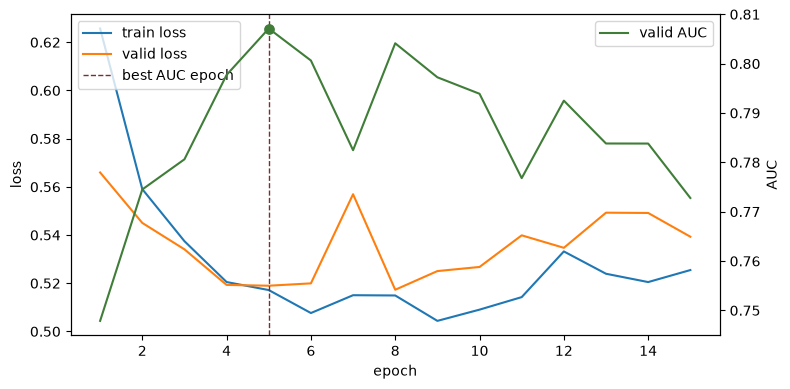

In [19]:
model, history, best_path = train_one_model(config, train_loader, valid_loader)
display(history)
best_row = history.loc[history['valid_auc'].idxmax()]
print('Best checkpoint:', best_path)
print(f"Best valid AUC: {best_row['valid_auc']:.5f} at epoch {int(best_row['epoch'])}")

fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(history['epoch'], history['train_loss'], label='train loss')
ax1.plot(history['epoch'], history['valid_loss'], label='valid loss')
ax1.axvline(best_row['epoch'], color='#7a2e2e', linestyle='--', linewidth=1, label='best AUC epoch')
ax1.set_xlabel('epoch')
ax1.set_ylabel('loss')
ax1.legend(loc='upper left')
if 'valid_auc' in history:
    ax2 = ax1.twinx()
    ax2.plot(history['epoch'], history['valid_auc'], color='#3f7d38', label='valid AUC')
    ax2.scatter([best_row['epoch']], [best_row['valid_auc']], color='#3f7d38', s=45)
    ax2.set_ylabel('AUC')
    ax2.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [21]:
def predict_test(model, test_df, batch_size=512):
    model.eval()
    test_frame = build_model_frame(test_df)
    dataset = TCRDataset(test_frame, include_label=False)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    preds = []
    with torch.no_grad():
        for batch in loader:
            batch = batch_to_device(batch, device)
            logits = model(batch['alpha'], batch['beta'], batch['peptide'], batch['hla'])
            preds.extend(torch.sigmoid(logits).detach().cpu().numpy().tolist())
    return np.array(preds)

checkpoint = torch.load(best_path, map_location=device)
model.load_state_dict(checkpoint['model'])
preds = predict_test(model, test, batch_size=512)
submission = sample_submission.copy()
submission['Prediction'] = preds
submission_path = OUTPUT_DIR / 'submission_rope_tcr_transformer.csv'
submission.to_csv(submission_path, index=False)
print(submission_path)
display(submission[['ID', 'Peptide', 'HLA', 'Prediction']].head())
print(submission['Prediction'].describe())

/home/Data_Drive_8TB/kykim/0. Jupyter/Kaggle/TCR-pred/output/submission_rope_tcr_transformer.csv


,ID,Peptide,HLA,Prediction
0,0,TVYPYGTSL,HLA-A*02:01,0.546449
1,1,SQFNWTIYL,HLA-A*02:01,0.531453
2,2,HLDDYPYLM,HLA-A*02:01,0.496086
3,3,TVYPYGTSL,HLA-A*02:01,0.527220
4,4,YLFNADIWI,HLA-A*02:01,0.502095


count    8938.000000
mean        0.506659
std         0.025726
min         0.355782
25%         0.496188
50%         0.504888
75%         0.522625
max         0.563706
Name: Prediction, dtype: float64


## Positional encoding validation plot


Running positional encoding experiment: sinusoidal
{'run_name': 'sinusoidal_pe_validation', 'positional_encoding': 'sinusoidal', 'epoch': 1, 'train_loss': 0.7037598399015573, 'valid_loss': 0.6997054815292358, 'valid_auc': 0.6048507475730531, 'valid_auprc': 0.5608449863204199, 'lr': 0.0006535075791188269, 'best_valid_auc': 0.6048507475730531, 'best_epoch': 1, 'epochs_without_improvement': 0, 'is_best': True}
{'run_name': 'sinusoidal_pe_validation', 'positional_encoding': 'sinusoidal', 'epoch': 2, 'train_loss': 0.6544896490298785, 'valid_loss': 0.7204622268676758, 'valid_auc': 0.6364540182270091, 'valid_auprc': 0.6574722604408636, 'lr': 0.0015569878179903763, 'best_valid_auc': 0.6364540182270091, 'best_epoch': 2, 'epochs_without_improvement': 0, 'is_best': True}
{'run_name': 'sinusoidal_pe_validation', 'positional_encoding': 'sinusoidal', 'epoch': 3, 'train_loss': 0.6594312608433075, 'valid_loss': 0.9699163675308228, 'valid_auc': 0.5303482847943956, 'valid_auprc': 0.5434296444853864, 'l

,positional_encoding,best_epoch,valid_auc,valid_auprc,valid_loss,best_path
0,sinusoidal,7,0.745922,0.731162,0.589684,/home/Data_Drive_8TB/kykim/0. Jupyter/Kaggle/T...
1,rope,20,0.768570,0.749725,0.566534,/home/Data_Drive_8TB/kykim/0. Jupyter/Kaggle/T...


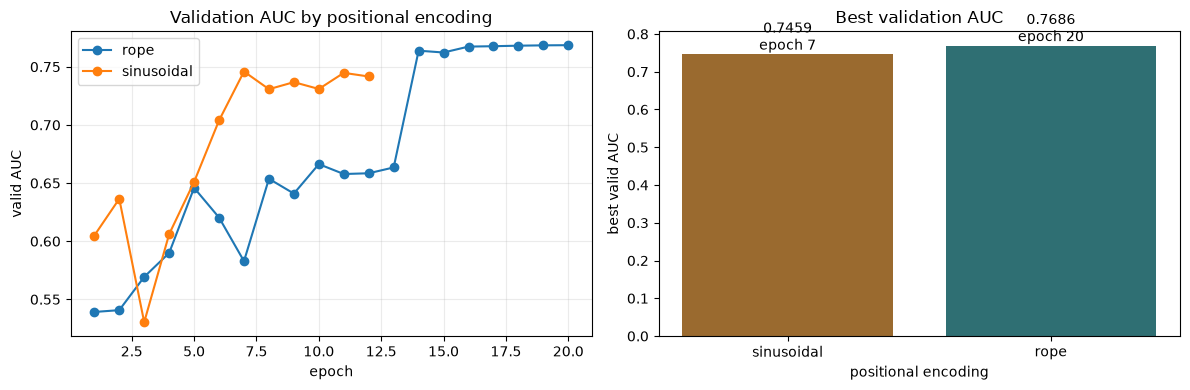

In [27]:
from dataclasses import replace

COMPARE_QUICK_RUN = True
COMPARE_ROWS = 12000
COMPARE_EPOCHS = 20
COMPARE_PATIENCE = 5
COMPARE_BATCH_SIZE = 256


def make_loaders_for_experiment(frame, cfg, seed=SEED):
    experiment_frame = frame
    valid_size = 0.15
    if cfg.quick_run:
        experiment_frame = frame.sample(min(len(frame), cfg.quick_rows), random_state=seed).reset_index(drop=True)
        valid_size = 0.2
    tr_frame, va_frame = split_train_valid(experiment_frame, test_size=valid_size, seed=seed)
    tr_loader = DataLoader(
        TCRDataset(tr_frame, include_label=True),
        batch_sampler=HLABatchSampler(tr_frame, batch_size=cfg.batch_size, shuffle=True, seed=seed),
        num_workers=0,
    )
    va_loader = DataLoader(TCRDataset(va_frame, include_label=True), batch_size=cfg.batch_size * 2, shuffle=False, num_workers=0)
    return tr_loader, va_loader


pe_histories = []
pe_best_rows = []
for pe_name in ['sinusoidal', 'rope']:
    experiment_config = replace(
        config,
        positional_encoding=pe_name,
        epochs=COMPARE_EPOCHS,
        early_stopping_patience=COMPARE_PATIENCE,
        quick_run=COMPARE_QUICK_RUN,
        quick_rows=COMPARE_ROWS,
        batch_size=COMPARE_BATCH_SIZE,
    )
    print('\nRunning positional encoding experiment:', pe_name)
    exp_train_loader, exp_valid_loader = make_loaders_for_experiment(model_frame, experiment_config, seed=SEED)
    exp_model, exp_history, exp_best_path = train_one_model(
        experiment_config,
        exp_train_loader,
        exp_valid_loader,
        run_name=f'{pe_name}_pe_validation',
    )
    exp_history['best_path'] = str(exp_best_path)
    pe_histories.append(exp_history)
    pe_best_rows.append(exp_history.loc[exp_history['valid_auc'].idxmax()].copy())
    del exp_model
    if device.type == 'cuda':
        torch.cuda.empty_cache()

pe_history = pd.concat(pe_histories, ignore_index=True)
pe_best = pd.DataFrame(pe_best_rows).reset_index(drop=True)
pe_history.to_csv(OUTPUT_DIR / 'positional_encoding_validation_history.csv', index=False)
pe_best.to_csv(OUTPUT_DIR / 'positional_encoding_validation_best.csv', index=False)

display(pe_best[['positional_encoding', 'best_epoch', 'valid_auc', 'valid_auprc', 'valid_loss', 'best_path']])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for pe_name, group in pe_history.groupby('positional_encoding'):
    axes[0].plot(group['epoch'], group['valid_auc'], marker='o', label=pe_name)
axes[0].set_title('Validation AUC by positional encoding')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('valid AUC')
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].bar(pe_best['positional_encoding'], pe_best['valid_auc'], color=['#9a6a2f', '#2f6f73'])
axes[1].set_title('Best validation AUC')
axes[1].set_xlabel('positional encoding')
axes[1].set_ylabel('best valid AUC')
for idx, row in pe_best.iterrows():
    axes[1].text(idx, row['valid_auc'], f"{row['valid_auc']:.4f}\nepoch {int(row['best_epoch'])}", ha='center', va='bottom')
plt.tight_layout()
plt.show()

## Model validation plots

1. ROC curve
2. Precision-Recall curve
3. Calibration curve
4. Confusion matrix at best F1 threshold
5. HLA subgroup AUC

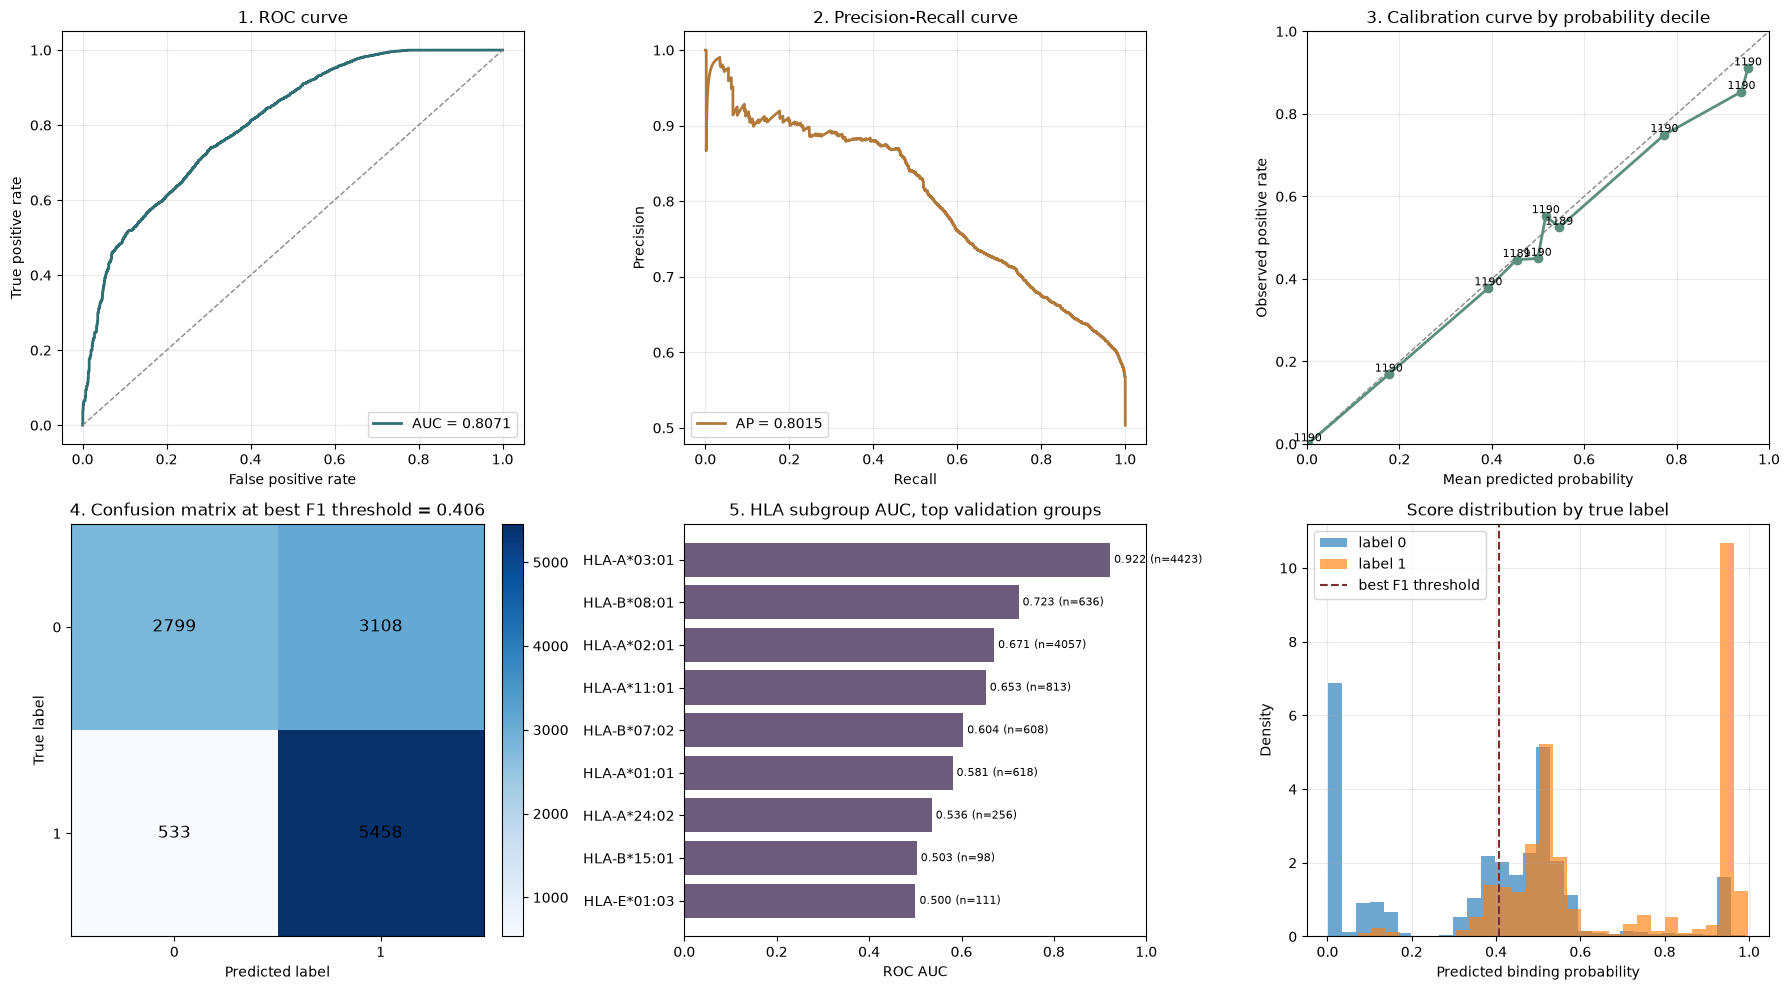

checkpoint: /home/Data_Drive_8TB/kykim/0. Jupyter/Kaggle/TCR-pred/output/best_rope_tcr_transformer.pt
best epoch: 5
validation ROC AUC: 0.80712
validation PR AUC: 0.80152
best F1 threshold: 0.40590


,hla,peptide_seq,label,y_prob,y_pred
0,HLA-A*03:01,RVRAYTYSK,0.0,0.001877,0
1,HLA-A*11:01,IVTDFSVIK,1.0,0.470431,1
2,HLA-A*03:01,KLGGALQAK,1.0,0.942603,1
3,HLA-A*03:01,KLGGALQAK,1.0,0.940209,1
4,HLA-A*02:01,SACVLAAEC,0.0,0.522906,1


In [30]:
from sklearn.metrics import confusion_matrix, precision_recall_curve, roc_curve


def load_best_validation_model(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    checkpoint_config = checkpoint.get('config', {})
    validation_model = TCRBindingTransformer(
        vocab_size=len(itos),
        hla_count=len(hla_to_idx),
        dim=checkpoint_config.get('dim', config.dim),
        heads=checkpoint_config.get('heads', config.heads),
        dropout=checkpoint_config.get('dropout', config.dropout),
        decoder_layers=checkpoint_config.get('decoder_layers', config.decoder_layers),
        positional_encoding=checkpoint_config.get('positional_encoding', 'rope'),
    ).to(device)
    validation_model.load_state_dict(checkpoint['model'])
    validation_model.eval()
    return validation_model, checkpoint


def collect_validation_predictions(validation_model, loader, frame):
    probabilities = []
    labels = []
    with torch.no_grad():
        for batch in loader:
            batch = batch_to_device(batch, device)
            logits = validation_model(batch['alpha'], batch['beta'], batch['peptide'], batch['hla'])
            probabilities.extend(torch.sigmoid(logits).detach().cpu().numpy().tolist())
            labels.extend(batch['label'].detach().cpu().numpy().tolist())

    prediction_frame = frame[['hla', 'alpha_seq', 'beta_seq', 'peptide_seq', 'label']].reset_index(drop=True).copy()
    prediction_frame['y_true'] = np.array(labels, dtype=int)
    prediction_frame['y_prob'] = np.array(probabilities, dtype=float)
    prediction_frame['alpha_len'] = prediction_frame['alpha_seq'].str.len()
    prediction_frame['beta_len'] = prediction_frame['beta_seq'].str.len()
    prediction_frame['peptide_len'] = prediction_frame['peptide_seq'].str.len()
    return prediction_frame


validation_model, validation_checkpoint = load_best_validation_model(best_path)
validation_predictions = collect_validation_predictions(validation_model, valid_loader, valid_frame)
validation_predictions.to_csv(OUTPUT_DIR / 'validation_predictions.csv', index=False)

fpr, tpr, roc_thresholds = roc_curve(validation_predictions['y_true'], validation_predictions['y_prob'])
precision, recall, pr_thresholds = precision_recall_curve(validation_predictions['y_true'], validation_predictions['y_prob'])
roc_auc = roc_auc_score(validation_predictions['y_true'], validation_predictions['y_prob'])
pr_auc = average_precision_score(validation_predictions['y_true'], validation_predictions['y_prob'])

f1_scores = 2 * precision[:-1] * recall[:-1] / np.clip(precision[:-1] + recall[:-1], 1e-12, None)
best_threshold = float(pr_thresholds[np.nanargmax(f1_scores)]) if len(pr_thresholds) else 0.5
validation_predictions['y_pred'] = (validation_predictions['y_prob'] >= best_threshold).astype(int)
cm = confusion_matrix(validation_predictions['y_true'], validation_predictions['y_pred'])

calibration_bins = pd.qcut(validation_predictions['y_prob'], q=10, duplicates='drop')
calibration = validation_predictions.groupby(calibration_bins, observed=True).agg(
    mean_pred=('y_prob', 'mean'),
    observed_rate=('y_true', 'mean'),
    n=('y_true', 'size'),
).reset_index(drop=True)

hla_auc_rows = []
for hla, group in validation_predictions.groupby('hla'):
    if len(group) >= 50 and group['y_true'].nunique() == 2:
        hla_auc_rows.append({'hla': hla, 'n': len(group), 'auc': roc_auc_score(group['y_true'], group['y_prob'])})
hla_auc = pd.DataFrame(hla_auc_rows).sort_values('n', ascending=False).head(10)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

axes[0].plot(fpr, tpr, color='#2f6f73', linewidth=2, label=f'AUC = {roc_auc:.4f}')
axes[0].plot([0, 1], [0, 1], color='#888888', linestyle='--', linewidth=1)
axes[0].set_title('1. ROC curve')
axes[0].set_xlabel('False positive rate')
axes[0].set_ylabel('True positive rate')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.25)

axes[1].plot(recall, precision, color='#b17a3a', linewidth=2, label=f'AP = {pr_auc:.4f}')
axes[1].set_title('2. Precision-Recall curve')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(loc='lower left')
axes[1].grid(alpha=0.25)

axes[2].plot([0, 1], [0, 1], color='#888888', linestyle='--', linewidth=1, label='Perfect calibration')
axes[2].plot(calibration['mean_pred'], calibration['observed_rate'], marker='o', color='#5b8e7d', linewidth=2)
for _, row in calibration.iterrows():
    axes[2].text(row['mean_pred'], row['observed_rate'], str(int(row['n'])), fontsize=8, ha='center', va='bottom')
axes[2].set_title('3. Calibration curve by probability decile')
axes[2].set_xlabel('Mean predicted probability')
axes[2].set_ylabel('Observed positive rate')
axes[2].set_xlim(0, 1)
axes[2].set_ylim(0, 1)
axes[2].grid(alpha=0.25)

im = axes[3].imshow(cm, cmap='Blues')
axes[3].set_title(f'4. Confusion matrix at best F1 threshold = {best_threshold:.3f}')
axes[3].set_xlabel('Predicted label')
axes[3].set_ylabel('True label')
axes[3].set_xticks([0, 1])
axes[3].set_yticks([0, 1])
for row_idx in range(cm.shape[0]):
    for col_idx in range(cm.shape[1]):
        axes[3].text(col_idx, row_idx, cm[row_idx, col_idx], ha='center', va='center', color='black', fontsize=12)
fig.colorbar(im, ax=axes[3], fraction=0.046, pad=0.04)

if not hla_auc.empty:
    hla_auc_plot = hla_auc.sort_values('auc')
    axes[4].barh(hla_auc_plot['hla'], hla_auc_plot['auc'], color='#6c5b7b')
    axes[4].set_xlim(0, 1)
    axes[4].set_title('5. HLA subgroup AUC, top validation groups')
    axes[4].set_xlabel('ROC AUC')
    for _, row in hla_auc_plot.iterrows():
        axes[4].text(row['auc'], row['hla'], f" {row['auc']:.3f} (n={int(row['n'])})", va='center', fontsize=8)
else:
    axes[4].text(0.5, 0.5, 'No HLA subgroup has enough positive and negative validation rows.', ha='center', va='center')
    axes[4].set_title('5. HLA subgroup AUC')
    axes[4].axis('off')

for label, group in validation_predictions.groupby('y_true'):
    axes[5].hist(group['y_prob'], bins=30, alpha=0.65, density=True, label=f'label {label}')
axes[5].axvline(best_threshold, color='#7a2e2e', linestyle='--', linewidth=1.5, label='best F1 threshold')
axes[5].set_title('Score distribution by true label')
axes[5].set_xlabel('Predicted binding probability')
axes[5].set_ylabel('Density')
axes[5].legend()
axes[5].grid(alpha=0.25)

plt.tight_layout()
plt.show()

print(f"checkpoint: {best_path}")
print(f"best epoch: {validation_checkpoint.get('best_epoch', 'NA')}")
print(f"validation ROC AUC: {roc_auc:.5f}")
print(f"validation PR AUC: {pr_auc:.5f}")
print(f"best F1 threshold: {best_threshold:.5f}")
display(validation_predictions[['hla', 'peptide_seq', 'label', 'y_prob', 'y_pred']].head())

## Attention validation plots

1. beta query to alpha key triadic attention heatmap
2. decoder layer 1 beta self-attention heatmap
3. decoder last layer beta self-attention heatmap
4. attention entropy by decoder layer/head
5. causal mask and padding leakage check

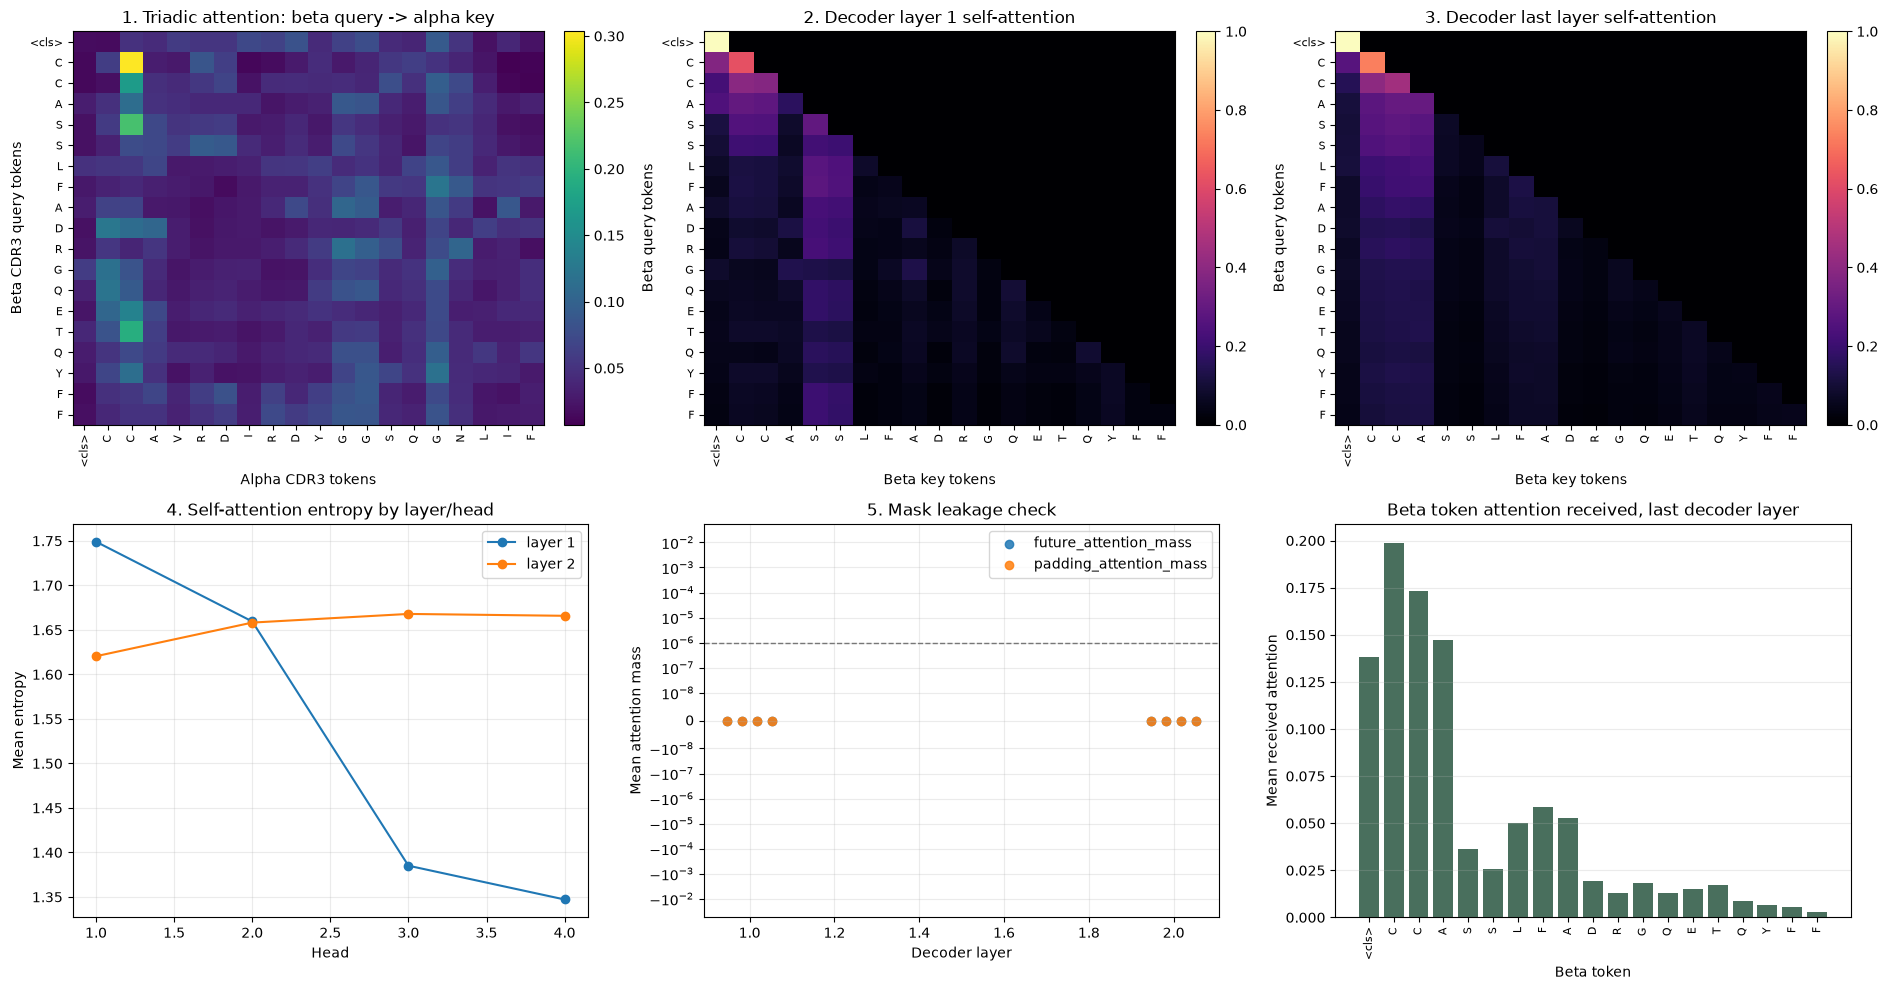

sample index in validation batch: 441
true label: 1
predicted probability: 0.997676432132721
alpha tokens: [CLS]CCAVRDIRDYGGSQGNLIF
beta tokens: [CLS]CCASSLFADRGQETQYFF
peptide tokens: [CLS]HPVTKYIM
attention validation summary: /home/Data_Drive_8TB/kykim/0. Jupyter/Kaggle/TCR-pred/output/attention_validation_summary.csv


,layer,head,entropy,future_attention_mass,padding_attention_mass
0,1,1,1.749000,0.0,0.0
1,1,2,1.659442,0.0,0.0
2,1,3,1.385100,0.0,0.0
3,1,4,1.347136,0.0,0.0
4,2,1,1.620407,0.0,0.0
5,2,2,1.658170,0.0,0.0
6,2,3,1.667893,0.0,0.0
7,2,4,1.665794,0.0,0.0


In [32]:
def token_labels(token_tensor):
    labels = []
    for token_id in token_tensor.detach().cpu().tolist():
        if token_id == PAD_IDX:
            continue
        labels.append(itos[token_id] if token_id < len(itos) else '<unk>')
    return labels


def attention_entropy(attn, valid_query_len, valid_key_len):
    clipped = attn[..., :valid_query_len, :valid_key_len]
    entropy = -(clipped * np.log(np.clip(clipped, 1e-12, 1.0))).sum(axis=-1)
    return entropy


attention_model, attention_checkpoint = load_best_validation_model(best_path)
attention_batch = next(iter(valid_loader))
attention_batch_device = batch_to_device(attention_batch, device)
with torch.no_grad():
    attention_logits = attention_model(
        attention_batch_device['alpha'],
        attention_batch_device['beta'],
        attention_batch_device['peptide'],
        attention_batch_device['hla'],
    )
attention_probs = torch.sigmoid(attention_logits).detach().cpu().numpy()

sample_candidates = np.where(attention_batch['label'].numpy() == 1)[0]
sample_idx = int(sample_candidates[np.argmax(attention_probs[sample_candidates])]) if len(sample_candidates) else int(np.argmax(attention_probs))
alpha_labels = token_labels(attention_batch['alpha'][sample_idx])
beta_labels = token_labels(attention_batch['beta'][sample_idx])
peptide_labels = token_labels(attention_batch['peptide'][sample_idx])
alpha_len = len(alpha_labels)
beta_len = len(beta_labels)

triadic_attn = attention_model.triadic_attention.last_attention.numpy()
triadic_sample = triadic_attn[sample_idx].mean(axis=0)[:beta_len, :alpha_len]
self_attn_layers = [block.last_self_attention.numpy() for block in attention_model.decoder]
self_first = self_attn_layers[0][sample_idx].mean(axis=0)[:beta_len, :beta_len]
self_last = self_attn_layers[-1][sample_idx].mean(axis=0)[:beta_len, :beta_len]

entropy_rows = []
mask_rows = []
for layer_idx, layer_attn in enumerate(self_attn_layers, start=1):
    for head_idx in range(layer_attn.shape[1]):
        head_attn = layer_attn[:, head_idx]
        valid_lengths = (attention_batch['beta'] != PAD_IDX).sum(dim=1).numpy()
        head_entropies = []
        future_mass = []
        padding_mass = []
        for batch_idx, valid_len in enumerate(valid_lengths):
            valid_len = int(valid_len)
            sample_attn = head_attn[batch_idx]
            valid_attn = sample_attn[:valid_len, :valid_len]
            head_entropies.append(attention_entropy(sample_attn[None, None], valid_len, valid_len).mean())
            future_mass.append(np.triu(valid_attn, k=1).sum() / max(valid_len, 1))
            if valid_len < sample_attn.shape[-1]:
                padding_mass.append(sample_attn[:valid_len, valid_len:].sum() / max(valid_len, 1))
            else:
                padding_mass.append(0.0)
        entropy_rows.append({'layer': layer_idx, 'head': head_idx + 1, 'entropy': float(np.mean(head_entropies))})
        mask_rows.append({
            'layer': layer_idx,
            'head': head_idx + 1,
            'future_attention_mass': float(np.mean(future_mass)),
            'padding_attention_mass': float(np.mean(padding_mass)),
        })

entropy_df = pd.DataFrame(entropy_rows)
mask_df = pd.DataFrame(mask_rows)
attention_summary_path = OUTPUT_DIR / 'attention_validation_summary.csv'
entropy_df.merge(mask_df, on=['layer', 'head']).to_csv(attention_summary_path, index=False)

fig, axes = plt.subplots(2, 3, figsize=(19, 10))
axes = axes.ravel()

im0 = axes[0].imshow(triadic_sample, cmap='viridis', aspect='auto')
axes[0].set_title('1. Triadic attention: beta query -> alpha key')
axes[0].set_xlabel('Alpha CDR3 tokens')
axes[0].set_ylabel('Beta CDR3 query tokens')
axes[0].set_xticks(range(alpha_len))
axes[0].set_xticklabels(alpha_labels, rotation=90, fontsize=8)
axes[0].set_yticks(range(beta_len))
axes[0].set_yticklabels(beta_labels, fontsize=8)
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(self_first, cmap='magma', aspect='auto', vmin=0, vmax=max(self_first.max(), self_last.max()))
axes[1].set_title('2. Decoder layer 1 self-attention')
axes[1].set_xlabel('Beta key tokens')
axes[1].set_ylabel('Beta query tokens')
axes[1].set_xticks(range(beta_len))
axes[1].set_xticklabels(beta_labels, rotation=90, fontsize=8)
axes[1].set_yticks(range(beta_len))
axes[1].set_yticklabels(beta_labels, fontsize=8)
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

im2 = axes[2].imshow(self_last, cmap='magma', aspect='auto', vmin=0, vmax=max(self_first.max(), self_last.max()))
axes[2].set_title('3. Decoder last layer self-attention')
axes[2].set_xlabel('Beta key tokens')
axes[2].set_ylabel('Beta query tokens')
axes[2].set_xticks(range(beta_len))
axes[2].set_xticklabels(beta_labels, rotation=90, fontsize=8)
axes[2].set_yticks(range(beta_len))
axes[2].set_yticklabels(beta_labels, fontsize=8)
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

for layer_idx, group in entropy_df.groupby('layer'):
    axes[3].plot(group['head'], group['entropy'], marker='o', label=f'layer {layer_idx}')
axes[3].set_title('4. Self-attention entropy by layer/head')
axes[3].set_xlabel('Head')
axes[3].set_ylabel('Mean entropy')
axes[3].legend()
axes[3].grid(alpha=0.25)

mask_plot = mask_df.melt(id_vars=['layer', 'head'], value_vars=['future_attention_mass', 'padding_attention_mass'], var_name='check', value_name='attention_mass')
for check_name, group in mask_plot.groupby('check'):
    x = group['layer'] + (group['head'] - group['head'].mean()) * 0.035
    axes[4].scatter(x, group['attention_mass'], label=check_name, alpha=0.85)
axes[4].axhline(1e-6, color='#777777', linestyle='--', linewidth=1)
axes[4].set_title('5. Mask leakage check')
axes[4].set_xlabel('Decoder layer')
axes[4].set_ylabel('Mean attention mass')
axes[4].set_yscale('symlog', linthresh=1e-8)
axes[4].legend()
axes[4].grid(alpha=0.25)

received_attention = self_last.sum(axis=0) / max(beta_len, 1)
axes[5].bar(range(beta_len), received_attention, color='#496f5d')
axes[5].set_title('Beta token attention received, last decoder layer')
axes[5].set_xlabel('Beta token')
axes[5].set_ylabel('Mean received attention')
axes[5].set_xticks(range(beta_len))
axes[5].set_xticklabels(beta_labels, rotation=90, fontsize=8)
axes[5].grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.show()

print('sample index in validation batch:', sample_idx)
print('true label:', int(attention_batch['label'][sample_idx].item()))
print('predicted probability:', float(attention_probs[sample_idx]))
print('alpha tokens:', ''.join(alpha_labels).replace('<cls>', '[CLS]'))
print('beta tokens:', ''.join(beta_labels).replace('<cls>', '[CLS]'))
print('peptide tokens:', ''.join(peptide_labels).replace('<cls>', '[CLS]'))
print('attention validation summary:', attention_summary_path)
display(entropy_df.merge(mask_df, on=['layer', 'head']))

## Decoder attention cosine similarity


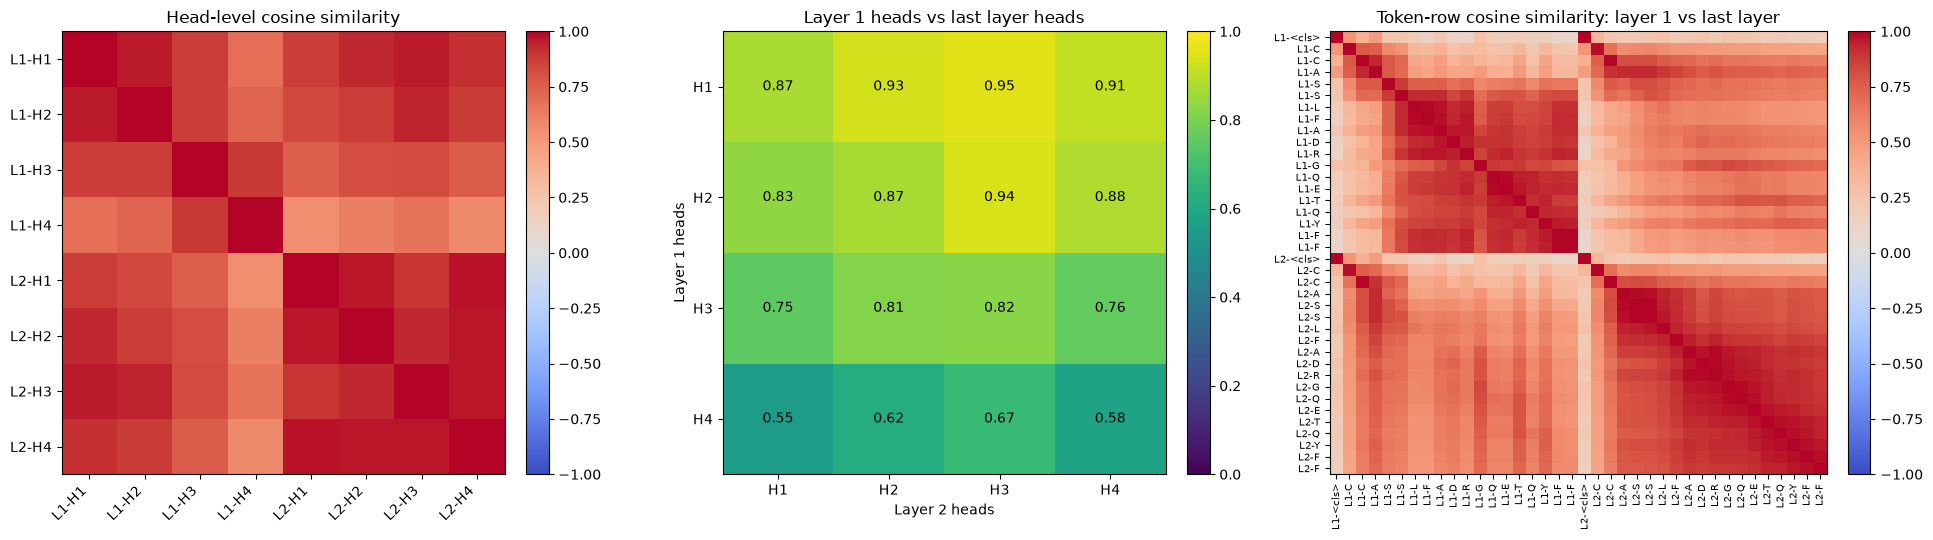

,comparison,cosine_similarity
0,mean_L1_vs_last_head_similarity,0.797375
1,min_L1_vs_last_head_similarity,0.552361
2,max_L1_vs_last_head_similarity,0.953559


In [33]:
def cosine_similarity_matrix(vectors):
    vectors = np.asarray(vectors, dtype=float)
    norms = np.linalg.norm(vectors, axis=1, keepdims=True)
    vectors = vectors / np.clip(norms, 1e-12, None)
    return vectors @ vectors.T


valid_beta_len = beta_len
first_layer_heads = self_attn_layers[0][sample_idx, :, :valid_beta_len, :valid_beta_len]
last_layer_heads = self_attn_layers[-1][sample_idx, :, :valid_beta_len, :valid_beta_len]
all_head_mats = np.concatenate([first_layer_heads, last_layer_heads], axis=0)
head_labels = [f'L1-H{idx + 1}' for idx in range(first_layer_heads.shape[0])] + [f'L{len(self_attn_layers)}-H{idx + 1}' for idx in range(last_layer_heads.shape[0])]
head_similarity = cosine_similarity_matrix(all_head_mats.reshape(all_head_mats.shape[0], -1))

query_similarity = cosine_similarity_matrix(np.vstack([self_first, self_last]))
query_labels = [f'L1-{token}' for token in beta_labels] + [f'L{len(self_attn_layers)}-{token}' for token in beta_labels]

layer_pair_similarity = np.zeros((first_layer_heads.shape[0], last_layer_heads.shape[0]))
for i in range(first_layer_heads.shape[0]):
    for j in range(last_layer_heads.shape[0]):
        a = first_layer_heads[i].reshape(1, -1)
        b = last_layer_heads[j].reshape(1, -1)
        layer_pair_similarity[i, j] = cosine_similarity_matrix(np.vstack([a, b]))[0, 1]

fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))

im0 = axes[0].imshow(head_similarity, cmap='coolwarm', vmin=-1, vmax=1)
axes[0].set_title('Head-level cosine similarity')
axes[0].set_xticks(range(len(head_labels)))
axes[0].set_yticks(range(len(head_labels)))
axes[0].set_xticklabels(head_labels, rotation=45, ha='right')
axes[0].set_yticklabels(head_labels)
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(layer_pair_similarity, cmap='viridis', vmin=0, vmax=1)
axes[1].set_title('Layer 1 heads vs last layer heads')
axes[1].set_xlabel(f'Layer {len(self_attn_layers)} heads')
axes[1].set_ylabel('Layer 1 heads')
axes[1].set_xticks(range(last_layer_heads.shape[0]))
axes[1].set_yticks(range(first_layer_heads.shape[0]))
axes[1].set_xticklabels([f'H{i + 1}' for i in range(last_layer_heads.shape[0])])
axes[1].set_yticklabels([f'H{i + 1}' for i in range(first_layer_heads.shape[0])])
for i in range(layer_pair_similarity.shape[0]):
    for j in range(layer_pair_similarity.shape[1]):
        axes[1].text(j, i, f'{layer_pair_similarity[i, j]:.2f}', ha='center', va='center', color='white' if layer_pair_similarity[i, j] < 0.55 else 'black')
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

im2 = axes[2].imshow(query_similarity, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
axes[2].set_title('Token-row cosine similarity: layer 1 vs last layer')
axes[2].set_xticks(range(len(query_labels)))
axes[2].set_yticks(range(len(query_labels)))
axes[2].set_xticklabels(query_labels, rotation=90, fontsize=7)
axes[2].set_yticklabels(query_labels, fontsize=7)
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

summary = pd.DataFrame({
    'comparison': ['mean_L1_vs_last_head_similarity', 'min_L1_vs_last_head_similarity', 'max_L1_vs_last_head_similarity'],
    'cosine_similarity': [layer_pair_similarity.mean(), layer_pair_similarity.min(), layer_pair_similarity.max()],
})
summary.to_csv(OUTPUT_DIR / 'decoder_attention_cosine_similarity.csv', index=False)
display(summary)